### Neural Network Project - Image Classification on CIFAR-10

In [2]:
# 1. Applying Learned Concepts to a More Complex Dataset.
    # Why CIFAR-10?
        # The CIFAR-10 dataset is a challenging benchmark dataset for imgage classification.
        # It contains 60 000 32x32 color images across 10 classes (e.g., airplane, car, bird, dog)
        # Unlike MNIST, CIFAR-10 involves more complex patterns and requires robust neural network acrhitectures.

# 2. Building and Optimizing a Neural Network for Image Classification.
    # Key Steps:
        # Preprocess the dataset for training (e.g., normalization, one-hot encoding).
        # Define a neural network with convolutional layers for feature extraction.
        # Optimize the network using techiques like learning rate adjustment and dropout.

# 3. Analysing Model Performance and Experiment with Hyperparameters.
    # Performance Analysis.
        # Evaluate accuracy and loss curves during training.
        # Use test set metrics to measure generalization.
    # Experimentation.
        # Try different activation functions (e.g., ReLu, Tanh)
        # Test optimizers like SGD, Adam, and RMSprop.
        # Adjust the learning rate and regularization techniques (e.g., dropot, weght decay).

#### Hands On Project

Training Data Shape: (50000, 32, 32, 3), (50000, 10)
Testing Data Shape: (10000, 32, 32, 3), (10000, 10)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 44ms/step - accuracy: 0.3809 - loss: 1.6908 - val_accuracy: 0.5200 - val_loss: 1.3732
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.5000 - loss: 1.3906 - val_accuracy: 0.5766 - val_loss: 1.2164
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.5520 - loss: 1.2588 - val_accuracy: 0.6023 - val_loss: 1.1262
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.5848 - loss: 1.1723 - val_accuracy: 0.6335 - val_loss: 1.0481
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.6089 - loss: 1.1056 - val_accuracy: 0.6511 - val_loss: 0.9959
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.6288 - loss: 1.0542 - val_accuracy: 0.6644 - val_loss: 0.9613
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.6424 - loss: 1.0178 - val_accuracy: 0.6630 - val_loss: 0.9501
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.6574 - loss: 0.9698 - 

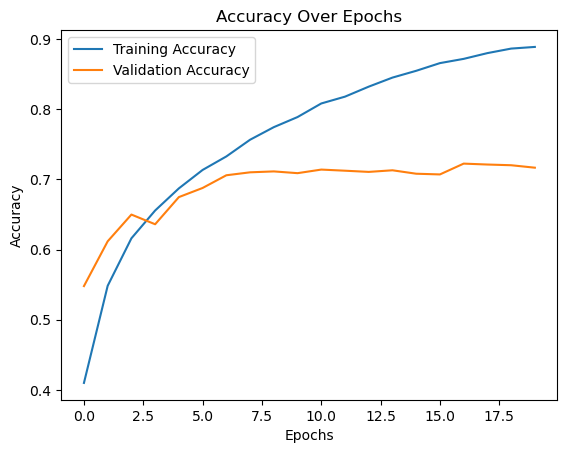

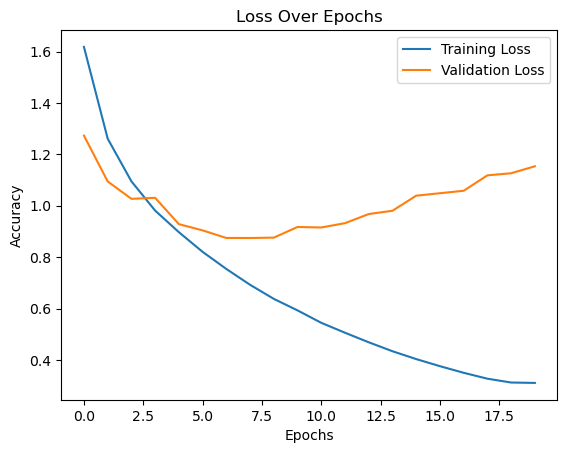

In [19]:
# Objective: Build, train, and optimize a neural network for CIFAR-10 image classification, experimenting with hyperparameters to improve performance.

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical # For one-hot encoding
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Conv2D, MaxPooling2D, Dense, Dropout
import matplotlib.pyplot as plt

# Load CIFAR-10 dataset.
# Have to load CIFAR-10 manual beause of connection errors.
import os
import pickle
import numpy as np
def load_cifar10_from_local(folder_path):
    def load_batch(file):
        with open(file, 'rb') as f:
            batch = pickle.load(f, encoding='bytes')
            data = batch[b'data']
            labels = batch[b'labels']
            return data, labels

    X_train = []
    y_train = []

    # Load training batches
    for i in range(1, 6):
        data, labels = load_batch(os.path.join(folder_path, f"data_batch_{i}"))
        X_train.append(data)
        y_train.extend(labels)

    X_train = np.concatenate(X_train)
    y_train = np.array(y_train)

    # Load test batch
    X_test, y_test = load_batch(os.path.join(folder_path, "test_batch"))
    y_test = np.array(y_test)

    # Reshape to image format
    X_train = X_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    X_test = X_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

    return (X_train, y_train), (X_test, y_test)
cifar_path = "C:/Users/F5153891/.keras/datasets/cifar-10-batches-py-target"

(X_train, y_train), (X_test, y_test) = load_cifar10_from_local(cifar_path)

# Normalise pixel values to [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# One-hot encoding target values.
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(f"Training Data Shape: {X_train.shape}, {y_train.shape}")
print(f"Testing Data Shape: {X_test.shape}, {y_test.shape}")

# Define the  baseline model.
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)), # First, Input hidden layer
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation="relu"), # Second, Input hidden layer
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation="relu"), # Third, Input hidden layer
    Dropout(0.5),
    Dense(10, activation="softmax") # Last, Output layer
])

# Comiple the model.
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Display the model summary.
model.summary()

# Train basline model.
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# Evaluate the model.
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Baseline Model Test Accuracy: {accuracy:.4f}")

# Define improved model.
improved_model = Sequential([
    Conv2D(64, (5, 5), activation="relu", input_shape=(32, 32, 3)), # First, Input hidden layer
    MaxPooling2D((2, 2)),
    Conv2D(128, (5, 5), activation="relu"), # Second, Input hidden layer
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation="relu"), # Third, Input hidden layer
    Dropout(0.5),
    Dense(10, activation="softmax") # Last, Output lay
])

# Compile the improved model with a learning rate scheduler.
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
improved_model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])

# Train improved mpodel.
improved_history = improved_model.fit(
    X_train, y_train,
    epochs=20,
    validation_split=0.2,
    batch_size=64,
    verbose=1
)

# Evaluate improved model.
improved_loss, improved_accuracy = improved_model.evaluate(X_test, y_test, verbose=0)
print(f"Improved Model Test Accuracy: {improved_accuracy:.4f}")

# Plot training and validation accuracy.
plt.plot(improved_history.history["accuracy"], label="Training Accuracy")
plt.plot(improved_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Plot training and validation los.
plt.plot(improved_history.history["loss"], label="Training Loss")
plt.plot(improved_history.history["val_loss"], label="Validation Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()